# 0. Environment Setup and Installations

In [ ]:
# 0. Environment Setup and Installations

# 1. Mount Google Drive to access your files
from google.colab import drive
import os
drive.mount('/content/drive', force_remount=True)

# 2. Extract the balanced dataset directly to the working directory
print("Unzipping Dataset... this might take a few minutes.")
!rm -rf /content/dataset
os.makedirs("/content/dataset", exist_ok=True)
zip_path = "/content/drive/MyDrive/Deepfake_Project/DFDC_Img.zip"
!unzip -q "{zip_path}" -d "/content/dataset"
print("Unzip complete!")

# 3. Install necessary libraries
print("Installing required libraries...")
!pip install -q transformers accelerate bitsandbytes torch torchvision Pillow tqdm pandas scikit-learn matplotlib seaborn
print("Installations complete! Ready for Data Extraction.")

Mounted at /content/drive
Unzipping Dataset... this might take a few minutes.
Unzip complete!
Installing required libraries...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 40.8 MB/s eta 0:00:00
Installations complete! Ready for Data Extraction.


# 1 Copy Img paths from Drive + dfdc split generator

In [ ]:
# 1. DFDC Split Generator (Run once - saved to Drive to prevent data leakage)
import os, glob, json, random

SPLIT_JSON_PATH = '/content/drive/MyDrive/Deepfake_Project/dfdc_split.json'
SEED = 42
TRAIN_PER_CLASS = 6232

# If the split already exists on Drive, just load it
if os.path.exists(SPLIT_JSON_PATH):
    with open(SPLIT_JSON_PATH, 'r') as f:
        split = json.load(f)
    print("Loaded existing split from Drive.")

else:
    # Collect all paths from both train and validation folders into one pool
    base = '/content/dataset'
    fake_paths = (
        glob.glob(os.path.join(base, 'train', 'fake', '**', '*.*'), recursive=True) +
        glob.glob(os.path.join(base, 'validation', 'fake', '**', '*.*'), recursive=True)
    )
    real_paths = (
        glob.glob(os.path.join(base, 'train', 'real', '**', '*.*'), recursive=True) +
        glob.glob(os.path.join(base, 'validation', 'real', '**', '*.*'), recursive=True)
    )
    fake_paths = [p for p in fake_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))]
    real_paths = [p for p in real_paths if p.lower().endswith(('.png', '.jpg', '.jpeg'))]

    print("Data Loading Summary:")
    print(f"Found {len(real_paths)} REAL images.")
    print(f"Found {len(fake_paths)} FAKE images.")
    print(f"Total: {len(real_paths) + len(fake_paths)} images accurately loaded and mapped.")

    # Shuffle with fixed seed to ensure reproducibility
    random.seed(SEED)
    random.shuffle(real_paths)
    random.shuffle(fake_paths)

    # Split: 10% balanced for training, rest for evaluation
    split = {
        'train': {
            'real': real_paths[:TRAIN_PER_CLASS],
            'fake': fake_paths[:TRAIN_PER_CLASS]
        },
        'test': {
            'real': real_paths[TRAIN_PER_CLASS:],
            'fake': fake_paths[TRAIN_PER_CLASS:]
        }
    }

    # Save to Drive - this file is the single source of truth for all future runs
    with open(SPLIT_JSON_PATH, 'w') as f:
        json.dump(split, f)
    print(f"Split saved to Drive: {SPLIT_JSON_PATH}")

# Summary
print(f"\nSplit Summary:")
print(f"Train — REAL: {len(split['train']['real'])} | FAKE: {len(split['train']['fake'])}")
print(f"Test  — REAL: {len(split['test']['real'])} | FAKE: {len(split['test']['fake'])}")
print(f"Total Test images: {len(split['test']['real']) + len(split['test']['fake'])}")

Loaded existing split from Drive.

Split Summary:
Train — REAL: 6232 | FAKE: 6232
Test  — REAL: 20496 | FAKE: 91687
Total Test images: 112183


#2. Model Initialization

In [ ]:
from transformers import InstructBlipProcessor, InstructBlipForConditionalGeneration
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"  #Processor Selection

print(" Loading Processor...")
processor = InstructBlipProcessor.from_pretrained("Salesforce/instructblip-vicuna-7b")

print(" Loading Base Model in bfloat16 for Maximum Efficiency...")
model = InstructBlipForConditionalGeneration.from_pretrained(
    "Salesforce/instructblip-vicuna-7b",
    torch_dtype=torch.bfloat16
).to(device)

# --- ZERO-SHOT OPTIMIZATION ---
# at zero-shot Freeze all the model weights to save Vram
for param in model.parameters():
    param.requires_grad = False

model.eval() # Enter the model to evaluation mode

print(" Model loaded successfully and fully frozen for pure Zero-Shot inference!")

 Loading Processor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/80.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/104k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1096 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

 Model loaded successfully and fully frozen for pure Zero-Shot inference!




# 3. Dataset Loading

In [ ]:
# 3. Dataset Loading

import os
import json
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import multiprocessing

class PreExtractedDeepfakeDataset(Dataset):
    def __init__(self, data_frame, processor):
        self.data = data_frame
        self.processor = processor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image_path = row['image_path']
        label_str = row['label']

        image = Image.open(image_path).convert('RGB')
        prompt = "is this photo real?"

        inputs = self.processor(images=image, text=prompt, return_tensors="pt")
        inputs = {k: v.squeeze(0) for k, v in inputs.items()}
        inputs['text_label'] = label_str
        return inputs

# Load split from Drive
SPLIT_JSON_PATH = '/content/drive/MyDrive/Deepfake_Project/dfdc_split.json'
with open(SPLIT_JSON_PATH, 'r') as f:
    split = json.load(f)

# Build test DataFrame from JSON (Zero-Shot uses test split only)
test_paths  = split['test']['real'] + split['test']['fake']
test_labels = ['Yes'] * len(split['test']['real']) + ['No'] * len(split['test']['fake'])

test_df = pd.DataFrame({'image_path': test_paths, 'label': test_labels})
print(f"Testing images (Zero-Shot DFDC): {len(test_df)}")

# Create Dataset and DataLoader
test_dataset = PreExtractedDeepfakeDataset(test_df, processor)
optimal_workers = min(8, multiprocessing.cpu_count())

test_dataloader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=optimal_workers,
    pin_memory=True,
    prefetch_factor=2
)
print("test_dataloader created successfully for Zero-Shot DFDC!")

Testing images (Zero-Shot DFDC): 112183
test_dataloader created successfully for Zero-Shot DFDC!


# 4. Model Evaluation and Metrics

In [ ]:
# --- 4. Probabilistic Evaluation Loop + Embeddings Extraction (CelebA-HQ Zero-Shot) ---

import os
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score
import numpy as np
from tqdm import tqdm

model.eval()

all_fake_probabilities = []
all_true_numerical_labels = []
all_embeddings = [] # Added for t-SNE

# Define tokens and extract de-duplicated token IDs
yes_tokens = ["Yes", "yes", " Yes", " yes"]
no_tokens  = ["No",  "no",  " No",  " no"]
yes_token_ids = list(set([processor.tokenizer.encode(t, add_special_tokens=False)[-1] for t in yes_tokens]))
no_token_ids  = list(set([processor.tokenizer.encode(t, add_special_tokens=False)[-1] for t in no_tokens]))

yes_tensor = torch.tensor(yes_token_ids, device=device)
no_tensor  = torch.tensor(no_token_ids, device=device)

print("--- Starting Zero-Shot Inference on DFDC ---")
print(f"Tokenizer Padding Side: {processor.tokenizer.padding_side}")

with torch.no_grad():
    for batch_idx, batch in enumerate(tqdm(test_dataloader, desc="Evaluating Test Set")):

        pixel_values = batch['pixel_values'].to(device, dtype=torch.bfloat16)
        qformer_input_ids = batch['qformer_input_ids'].to(device)
        qformer_attention_mask = batch['qformer_attention_mask'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        # Robust True Label Extraction
        text_labels = batch['text_label']
        numerical_labels = torch.tensor(
            [1 if "no" in str(label).lower() or "fake" in str(label).lower() else 0 for label in text_labels]
        )

        # ----------------- 1. Embeddings extraction ----------------------
        # Extract deep features from the Q-Former for t-SNE
        qformer_outputs = model.qformer(
            input_ids=qformer_input_ids,
            attention_mask=qformer_attention_mask,
            query_embeds=model.query_tokens.expand(pixel_values.shape[0], -1, -1),
            encoder_hidden_states=model.vision_model(pixel_values).last_hidden_state,
        )
        embedding = qformer_outputs.last_hidden_state.mean(dim=1)
        all_embeddings.extend(embedding.cpu().float().numpy())

        # ------------------ 2. Probabilistic inference -------------------
        outputs = model.generate(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            qformer_input_ids=qformer_input_ids,
            qformer_attention_mask=qformer_attention_mask,
            max_new_tokens=1,
            return_dict_in_generate=True,
            output_scores=True
        )

        first_token_logits = outputs.scores[0]

        # Extract logits using MAX over de-duplicated IDs
        yes_logits = first_token_logits[:, yes_tensor].max(dim=-1).values
        no_logits  = first_token_logits[:, no_tensor].max(dim=-1).values

        # Normalize via softmax over the {Yes, No} subset
        pair_logits = torch.stack([yes_logits, no_logits], dim=-1)
        pair_probs  = torch.softmax(pair_logits, dim=-1)
        fake_probability = pair_probs[:, 1]

        # Collect results
        all_fake_probabilities.extend(fake_probability.cpu().tolist())
        all_true_numerical_labels.extend(numerical_labels.tolist())

# ------------------------- Metrics & Saving --------------------------------
all_probs  = np.array(all_fake_probabilities)
all_labels = np.array(all_true_numerical_labels)

# Save arrays to Drive
save_dir = '/content/drive/MyDrive/Deepfake_Project/ZeroShot_Results_DFDC'
os.makedirs(save_dir, exist_ok=True)
np.save(f'{save_dir}/ZeroShot_probs.npy', all_probs)
np.save(f'{save_dir}/ZeroShot_labels.npy', all_labels)
np.save(f'{save_dir}/ZeroShot_embeddings.npy', np.array(all_embeddings))
print(f"Saved inference results to: {save_dir}")

# Calculate metrics
auc_score = roc_auc_score(all_labels, all_probs)

# Find optimal threshold iteratively
thresholds = np.arange(0.1, 0.91, 0.01)
accuracies = [accuracy_score(all_labels, (all_probs >= t).astype(int)) for t in thresholds]
best_idx = np.argmax(accuracies)
best_thresh = thresholds[best_idx]
best_acc = accuracies[best_idx]

# Calculate advanced industry metrics
binary_preds = (all_probs >= best_thresh).astype(int)
f1 = f1_score(all_labels, binary_preds)
precision = precision_score(all_labels, binary_preds)
recall = recall_score(all_labels, binary_preds)

print(f"\nFinal Test ROC-AUC Score: {auc_score:.4f}")
print(f"Optimal Threshold: {best_thresh:.2f} | ACC: {best_acc*100:.2f}% | F1: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")

--- Starting Zero-Shot Inference on DFDC ---
Tokenizer Padding Side: left


Evaluating Test Set: 100%|██████████| 3506/3506 [19:38<00:00,  2.98it/s]


Saved inference results to: /content/drive/MyDrive/Deepfake_Project/ZeroShot_Results_DFDC

Final Test ROC-AUC Score: 0.5334
Optimal Threshold: 0.10 | ACC: 79.05% | F1: 0.8821 | Precision: 0.8169 | Recall: 0.9585


#5.Graphs

Calculating Bootstrap Confidence Intervals (1000 iterations)...
Final ROC-AUC: 0.5334 (95% CI: [0.5294, 0.5376])


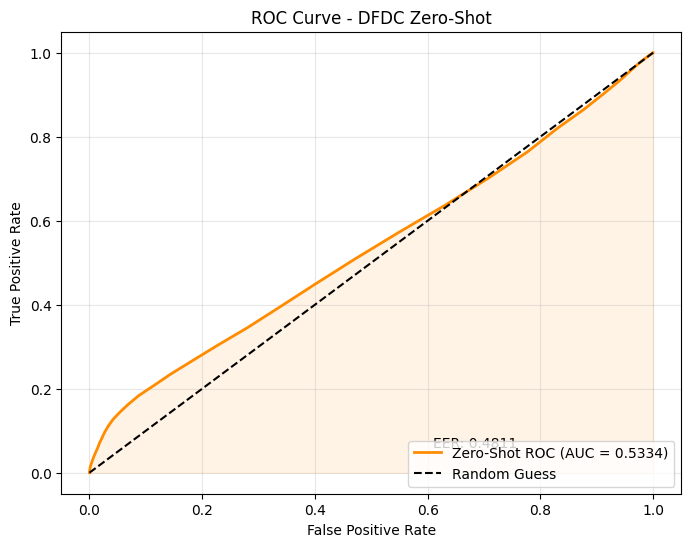

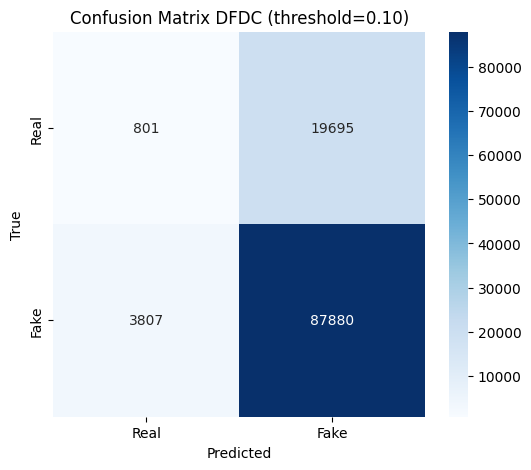

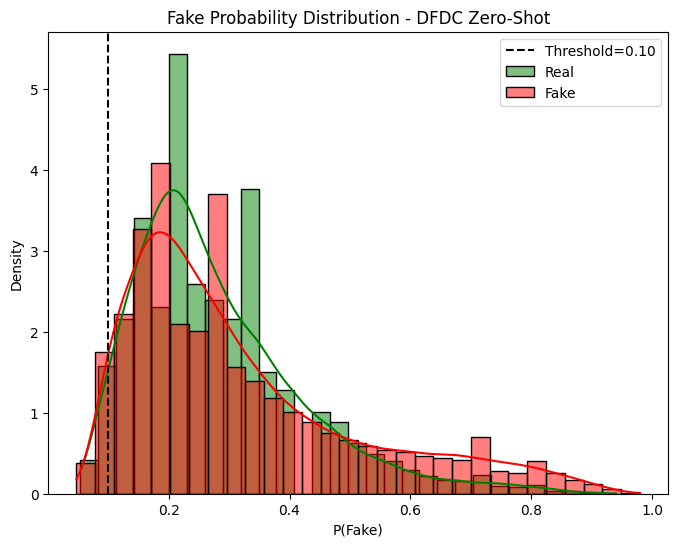

Generating t-SNE Visualization...
Silhouette Score: 0.0249


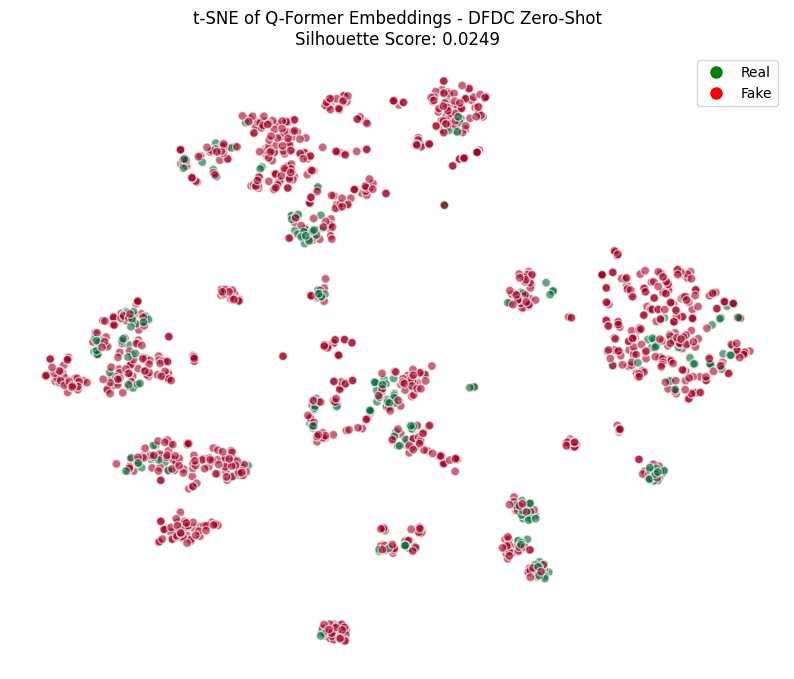


✅ All graphs saved to: /content/drive/MyDrive/Deepfake_Project/ZeroShot_Results_DFDC/Graphs


In [ ]:
# --- 5. Advanced Metrics & Visualizations (DFDC Zero-Shot) ---

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix, silhouette_score, roc_auc_score
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D

# ---------------------------------------------------------
# Configuration & Paths
# ---------------------------------------------------------
base_results_dir = '/content/drive/MyDrive/Deepfake_Project/ZeroShot_Results_DFDC'
graph_dir = os.path.join(base_results_dir, 'Graphs')
os.makedirs(graph_dir, exist_ok=True)

# Set random seed for reproducibility
rng = np.random.RandomState(42)

# ==========================================
# 1. Bootstrap Confidence Intervals (95% CI)
# ==========================================
print("Calculating Bootstrap Confidence Intervals (1000 iterations)...")
bootstrapped_aucs = []

for _ in range(1000):
    indices = rng.randint(0, len(all_probs), len(all_probs))
    if len(np.unique(all_labels[indices])) < 2:
        continue
    bootstrapped_aucs.append(roc_auc_score(all_labels[indices], all_probs[indices]))

sorted_scores = np.sort(bootstrapped_aucs)
ci_lower = sorted_scores[int(0.025 * len(sorted_scores))]
ci_upper = sorted_scores[int(0.975 * len(sorted_scores))]
final_auc = roc_auc_score(all_labels, all_probs)
print(f"Final ROC-AUC: {final_auc:.4f} (95% CI: [{ci_lower:.4f}, {ci_upper:.4f}])")

# ==========================================
# 2. ROC Curve & EER
# ==========================================
fpr, tpr, _ = roc_curve(all_labels, all_probs)

# Calculate Equal Error Rate (EER)
fnr = 1 - tpr
eer_idx = np.argmin(np.abs(fpr - fnr))
eer = (fpr[eer_idx] + fnr[eer_idx]) / 2

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Zero-Shot ROC (AUC = {final_auc:.4f})')
plt.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# Add EER text
plt.text(0.6, 0.1, f'EER: {eer:.4f}', transform=plt.gca().transAxes, fontsize=10)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - DFDC Zero-Shot')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(graph_dir, 'roc_curve_zeroshot.png'), dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 3. Confusion Matrix
# ==========================================
binary_preds = (all_probs >= best_thresh).astype(int)
cm = confusion_matrix(all_labels, binary_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix DFDC (threshold={best_thresh:.2f})')
plt.savefig(os.path.join(graph_dir, 'confusion_matrix_zeroshot.png'), dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 4. Probability Distribution
# ==========================================
plt.figure(figsize=(8, 6))
sns.histplot([p for p,l in zip(all_probs, all_labels) if l==0],
             color='green', label='Real', kde=True, stat="density", alpha=0.5, bins=30)
sns.histplot([p for p,l in zip(all_probs, all_labels) if l==1],
             color='red',   label='Fake', kde=True, stat="density", alpha=0.5, bins=30)
plt.axvline(best_thresh, color='black', linestyle='--', label=f'Threshold={best_thresh:.2f}')
plt.xlabel('P(Fake)')
plt.ylabel('Density')
plt.title('Fake Probability Distribution - DFDC Zero-Shot')
plt.legend()
plt.savefig(os.path.join(graph_dir, 'prob_dist_zeroshot.png'), dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 5. t-SNE + Silhouette Score
# ==========================================
print("Generating t-SNE Visualization...")
# Sample up to 1500 embeddings to save time
sample_size = min(1500, len(all_embeddings))
indices = rng.choice(len(all_embeddings), sample_size, replace=False)
sampled_embeddings = np.array(all_embeddings)[indices]
sampled_labels     = all_labels[indices]

sil_score = silhouette_score(sampled_embeddings, sampled_labels)
print(f"Silhouette Score: {sil_score:.4f}")

embeddings_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(sampled_embeddings)

plt.figure(figsize=(10, 8))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
            c=sampled_labels, cmap=plt.cm.RdYlGn_r, alpha=0.6, edgecolors='w', s=40)
custom_lines = [Line2D([0],[0], marker='o', color='w', markerfacecolor='green', markersize=10),
                Line2D([0],[0], marker='o', color='w', markerfacecolor='red',   markersize=10)]
plt.legend(custom_lines, ['Real', 'Fake'])
plt.title(f't-SNE of Q-Former Embeddings - DFDC Zero-Shot\nSilhouette Score: {sil_score:.4f}')
plt.axis('off')
plt.savefig(os.path.join(graph_dir, 'tsne_zeroshot.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n All graphs saved to: {graph_dir}")